### Contents

1 Import libraries and dataset  
2 Data preparation  
3 The elbow technique  
4 k-means clustering

### 1 Import libraries and dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans
import pylab as pl

In [3]:
%matplotlib inline

In [4]:
path = r"C:\Users\cathe\OneDrive\Data Analysis\2 6 Schools in England and Wales\02 Data\Prepared Data"

In [5]:
df = pd.read_csv(os.path.join(path, 'complete_data_v2.csv'))

### 2 Data preparation

In [7]:
df.columns

Index(['Unnamed: 0', 'URN', 'Ofsted phase', 'School open date',
       'Admissions policy', 'Sixth form', 'Region', 'Local authority',
       'Postcode', 'IDACI quintile', 'Total pupils',
       'Inspection number of latest graded inspection', 'Inspection type',
       'Inspection type grouping', 'Inspection start date', 'Publication date',
       'School type at time of latest graded inspection', 'OE', 'QE', 'BA',
       'PD', 'LM', 'Previous graded inspection number',
       'Previous inspection start date', 'Previous publication date',
       'School type at time of previous graded inspection', 'Previous OE',
       'Previous QE', 'Previous BA', 'Previous PD', 'Previous LM',
       'LA Total Pop', 'LA 0-3yo', 'LA 4-10yo', 'LA 11-17yo', 'LA under 18s',
       'LA Pop Density'],
      dtype='object')

In [8]:
# Create appropriate dataframe for k-means by dropping non-numerical columns

df_num = df.drop(['Unnamed: 0', 'URN', 'Ofsted phase', 'School open date',
                  'Admissions policy', 'Sixth form', 'Region', 'Local authority', 'Postcode',
                  'Inspection number of latest graded inspection', 'Inspection type',
                  'Inspection type grouping', 'Inspection start date', 'Publication date',
                  'School type at time of latest graded inspection', 'Previous graded inspection number',
                  'Previous inspection start date', 'Previous publication date',
                  'School type at time of previous graded inspection'], axis=1)

In [9]:
df_num.columns

Index(['IDACI quintile', 'Total pupils', 'OE', 'QE', 'BA', 'PD', 'LM',
       'Previous OE', 'Previous QE', 'Previous BA', 'Previous PD',
       'Previous LM', 'LA Total Pop', 'LA 0-3yo', 'LA 4-10yo', 'LA 11-17yo',
       'LA under 18s', 'LA Pop Density'],
      dtype='object')

In [10]:
df_num.describe()

,IDACI quintile,Total pupils,OE,QE,BA,PD,LM,Previous OE,Previous QE,Previous BA,Previous PD,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density
count,12144.000000,12144.000000,12088.000000,12088.000000,12088.000000,12088.000000,12088.000000,11702.000000,11702.000000,11702.000000,11702.000000,11702.000000,1.214400e+04,12144.000000,12144.000000,12144.000000,12144.000000,12144.000000
mean,3.428030,427.339592,2.388154,5.197469,5.091413,5.058819,1.894358,2.217570,8.630320,8.599299,8.589643,2.119552,3.587602e+05,15885.487319,30376.473897,31459.265646,77721.226861,2909.526597
std,1.384468,375.706845,1.772835,3.496782,3.592137,3.619318,0.533800,0.823241,1.448744,1.574195,1.610194,0.807184,2.089270e+05,10404.266298,19882.771065,20543.612984,50748.401243,3087.751678
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.229000e+03,65.000000,146.000000,153.000000,364.000000,63.900000
25%,2.000000,197.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,9.000000,9.000000,9.000000,2.000000,2.346660e+05,10393.000000,20093.000000,20983.000000,51847.000000,584.300000
50%,4.000000,312.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,9.000000,9.000000,9.000000,2.000000,3.119760e+05,13790.000000,25251.000000,25956.000000,64341.000000,1787.000000
75%,5.000000,472.000000,2.000000,9.000000,9.000000,9.000000,2.000000,3.000000,9.000000,9.000000,9.000000,3.000000,3.848090e+05,17996.000000,34004.000000,34877.000000,86835.000000,4275.400000
max,5.000000,3077.000000,9.000000,9.000000,9.000000,9.000000,4.000000,4.000000,9.000000,9.000000,9.000000,4.000000,1.166049e+06,59343.000000,112795.000000,117343.000000,289481.000000,15702.900000


In [11]:
# Drop Previous QE, Previous BA and Previous PD since majority of entries are 9, which is placeholder for no entry

df_num = df_num.drop(['Previous QE', 'Previous BA', 'Previous PD'], axis=1)

In [12]:
df_num.describe()

,IDACI quintile,Total pupils,OE,QE,BA,PD,LM,Previous OE,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density
count,12144.000000,12144.000000,12088.000000,12088.000000,12088.000000,12088.000000,12088.000000,11702.000000,11702.000000,1.214400e+04,12144.000000,12144.000000,12144.000000,12144.000000,12144.000000
mean,3.428030,427.339592,2.388154,5.197469,5.091413,5.058819,1.894358,2.217570,2.119552,3.587602e+05,15885.487319,30376.473897,31459.265646,77721.226861,2909.526597
std,1.384468,375.706845,1.772835,3.496782,3.592137,3.619318,0.533800,0.823241,0.807184,2.089270e+05,10404.266298,19882.771065,20543.612984,50748.401243,3087.751678
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.229000e+03,65.000000,146.000000,153.000000,364.000000,63.900000
25%,2.000000,197.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.346660e+05,10393.000000,20093.000000,20983.000000,51847.000000,584.300000
50%,4.000000,312.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.119760e+05,13790.000000,25251.000000,25956.000000,64341.000000,1787.000000
75%,5.000000,472.000000,2.000000,9.000000,9.000000,9.000000,2.000000,3.000000,3.000000,3.848090e+05,17996.000000,34004.000000,34877.000000,86835.000000,4275.400000
max,5.000000,3077.000000,9.000000,9.000000,9.000000,9.000000,4.000000,4.000000,4.000000,1.166049e+06,59343.000000,112795.000000,117343.000000,289481.000000,15702.900000


In [13]:
# Test removing the records containing 9 in the OE column

df_num2 = df_num[df_num['OE'] != 9]

In [14]:
df_num2.shape

(11394, 15)

In [15]:
df_num.shape

(12144, 15)

Removing 9s from OE has not made the database too small

In [17]:
# Test removing the records containing 9 in columns QE, BA, PD

df_num3 = df_num2[(df_num2['QE'] != 9) & (df_num2['BA'] != 9) & (df_num2['PD'] != 9)]

In [18]:
df_num3.shape

(5902, 15)

This is roughly half the size of the previous dataframe.  Check the summary statistics again to decide how to proceed.

In [20]:
df_num3.describe()

,IDACI quintile,Total pupils,OE,QE,BA,PD,LM,Previous OE,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density
count,5902.000000,5902.000000,5846.000000,5846.000000,5846.000000,5846.000000,5846.000000,5657.000000,5657.000000,5.902000e+03,5902.000000,5902.000000,5902.000000,5902.000000,5902.000000
mean,3.484751,451.066757,2.056791,2.040541,1.851865,1.795587,1.999829,2.162984,2.074421,3.611795e+05,15930.462894,30504.781769,31613.565063,78048.809726,2845.297001
std,1.386754,393.766448,0.601558,0.580757,0.576962,0.548226,0.596970,0.874935,0.855929,2.091712e+05,10416.038728,19913.905820,20570.916194,50817.648735,3092.216017
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.229000e+03,65.000000,146.000000,153.000000,364.000000,63.900000
25%,2.000000,200.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.374800e+05,10525.000000,20093.000000,20983.000000,52031.000000,567.800000
50%,4.000000,327.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.141760e+05,13790.000000,25251.000000,26004.000000,65045.000000,1750.000000
75%,5.000000,533.250000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.950070e+05,17996.000000,34004.000000,34877.000000,86835.000000,4275.400000
max,5.000000,3077.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.166049e+06,59343.000000,112795.000000,117343.000000,289481.000000,15702.900000


The disadvantage of using this reduced-size dataset, despite its "cleanliness" is that it could have been unintentionally biassed.  I am instead going to use df_num2 with the cleaned OE column, and remove the columns QE, BA and PD for this task, so that the 9s don't unintentionally distort the results.

In [22]:
# Drop columns mentioned above
df_num2 = df_num2.drop(['QE', 'BA', 'PD'], axis=1)

In [23]:
# Standardisation of Total pupils, LA Population columns

df_num2['Total pupils'] = (df_num2['Total pupils'] - df_num2['Total pupils'].mean()) / df_num2['Total pupils'].std()
df_num2['LA Total Pop'] = (df_num2['LA Total Pop'] - df_num2['LA Total Pop'].mean()) / df_num2['LA Total Pop'].std()
df_num2['LA 0-3yo'] = (df_num2['LA 0-3yo'] - df_num2['LA 0-3yo'].mean()) / df_num2['LA 0-3yo'].std()
df_num2['LA 4-10yo'] = (df_num2['LA 4-10yo'] - df_num2['LA 4-10yo'].mean()) / df_num2['LA 4-10yo'].std()
df_num2['LA 11-17yo'] = (df_num2['LA 11-17yo'] - df_num2['LA 11-17yo'].mean()) / df_num2['LA 11-17yo'].std()
df_num2['LA under 18s'] = (df_num2['LA under 18s'] - df_num2['LA under 18s'].mean()) / df_num2['LA under 18s'].std()
df_num2['LA Pop Density'] = (df_num2['LA Pop Density'] - df_num2['LA Pop Density'].mean()) / df_num2['LA Pop Density'].std()

In [24]:
df_num2.describe()

,IDACI quintile,Total pupils,OE,LM,Previous OE,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density
count,11394.000000,1.139400e+04,11338.000000,11338.000000,10955.000000,10955.000000,1.139400e+04,1.139400e+04,1.139400e+04,1.139400e+04,1.139400e+04,1.139400e+04
mean,3.424346,7.483336e-17,1.950785,1.895837,2.234231,2.133638,1.371945e-16,-9.977781e-18,-2.993334e-17,-5.238335e-17,5.986669e-17,-9.977781e-18
std,1.383128,1.000000e+00,0.517195,0.528785,0.823305,0.807146,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,1.000000,-1.133154e+00,1.000000,1.000000,1.000000,1.000000,-1.706677e+00,-1.519744e+00,-1.519130e+00,-1.522604e+00,-1.523133e+00,-9.192707e-01
25%,2.000000,-6.130123e-01,2.000000,2.000000,2.000000,2.000000,-5.960311e-01,-5.168059e-01,-5.183575e-01,-5.112311e-01,-5.075453e-01,-7.522217e-01
50%,4.000000,-3.089294e-01,2.000000,2.000000,2.000000,2.000000,-2.266233e-01,-2.037473e-01,-2.595724e-01,-2.697737e-01,-2.655748e-01,-3.142799e-01
75%,5.000000,1.198542e-01,2.000000,2.000000,3.000000,3.000000,1.213922e-01,1.995373e-01,1.795796e-01,1.633735e-01,1.765767e-01,4.326255e-01
max,5.000000,7.071750e+00,4.000000,4.000000,4.000000,4.000000,3.854366e+00,4.164019e+00,4.132650e+00,4.167400e+00,4.159871e+00,4.100866e+00


### 3 The elbow technique

In [26]:
num_cl = range(1, 10)
kmeans = [KMeans(n_clusters=i) for i in num_cl]

In [27]:
score = [kmeans[i].fit(df_num2).score(df_num2) for i in range(len(kmeans))]

score

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [30]:
# Find missing values
df_num2.isnull().sum()

IDACI quintile      0
Total pupils        0
OE                 56
LM                 56
Previous OE       439
Previous LM       439
LA Total Pop        0
LA 0-3yo            0
LA 4-10yo           0
LA 11-17yo          0
LA under 18s        0
LA Pop Density      0
dtype: int64

In [31]:
# Remove records with missing values
df_num2 = df_num2[df_num2['Previous OE'].isnull() == False]

In [32]:
# Check missing values
df_num2.isnull().sum()

IDACI quintile    0
Total pupils      0
OE                0
LM                0
Previous OE       0
Previous LM       0
LA Total Pop      0
LA 0-3yo          0
LA 4-10yo         0
LA 11-17yo        0
LA under 18s      0
LA Pop Density    0
dtype: int64

In [33]:
# Repeat elbow technique step
score = [kmeans[i].fit(df_num2).score(df_num2) for i in range(len(kmeans))]

score

[-118302.77146422784,
 -80447.9780680585,
 -63925.36639569194,
 -57096.69259358109,
 -49171.826894872305,
 -44245.54866930634,
 -40994.84921839153,
 -38244.10021194481,
 -35787.91456631088]

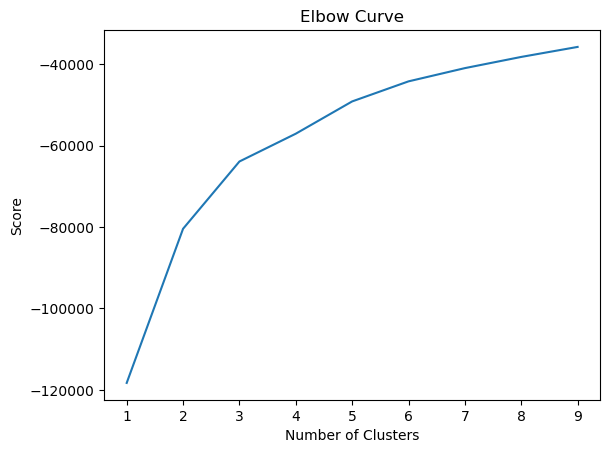

In [34]:
# Plot the elbow curve using PyLab.

pl.plot(num_cl,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

There are smaller jumps after 3, so I'll choose 3 clusters.

### 4 k-means clustering

In [37]:
# Create the k-means object
kmeans = KMeans(n_clusters = 3) 

In [38]:
# Fit the k-means object to the data
kmeans.fit(df_num2)

KMeans(n_clusters=3)

In [39]:
df_num2['clusters'] = kmeans.fit_predict(df_num2)

C:\Users\cathe\AppData\Local\Temp\ipykernel_15024\2195928319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num2['clusters'] = kmeans.fit_predict(df_num2)


In [40]:
df_num2.head()

,IDACI quintile,Total pupils,OE,LM,Previous OE,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density,clusters
0,4.0,-0.484977,1.0,1.0,1.0,1.0,-1.653003,-1.508430,-1.514665,-1.519157,-1.517669,0.015196,1
1,3.0,-0.807732,1.0,1.0,1.0,1.0,-0.661794,-0.755939,-0.844072,-0.818236,-0.816918,2.154957,1
2,3.0,-1.082474,2.0,1.0,2.0,2.0,-0.661794,-0.755939,-0.844072,-0.818236,-0.816918,2.154957,1
3,4.0,-1.087808,2.0,2.0,2.0,2.0,-0.661794,-0.755939,-0.844072,-0.818236,-0.816918,2.154957,1
4,4.0,-0.340938,2.0,2.0,2.0,2.0,-0.661794,-0.755939,-0.844072,-0.818236,-0.816918,2.154957,1


In [41]:
df_num2['clusters'].value_counts()

clusters
1    5889
0    4412
2     654
Name: count, dtype: int64

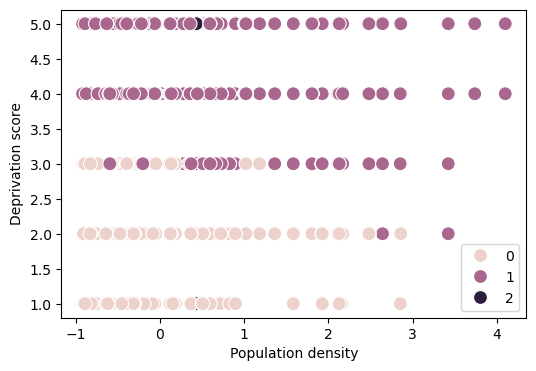

In [42]:
# View clusters in scatterplot from previous exercise

plt.figure(figsize=(6,4))
ax = sns.scatterplot(x=df_num2['LA Pop Density'], y=df_num2['IDACI quintile'], hue=kmeans.labels_, s=100) 

ax.grid(False) # This removes the grid from the background.
plt.xlabel('Population density') # Label x-axis.
plt.ylabel('Deprivation score') # Label y-axis.
plt.show()

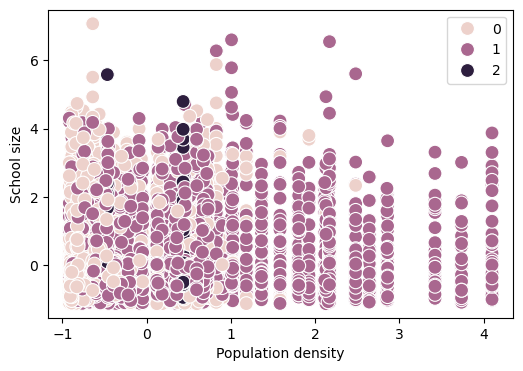

In [43]:
# Investigate school size and population density

plt.figure(figsize=(6,4))
ax = sns.scatterplot(x=df_num2['LA Pop Density'], y=df_num2['Total pupils'], hue=kmeans.labels_, s=100) 

ax.grid(False) # This removes the grid from the background.
plt.xlabel('Population density') # Label x-axis.
plt.ylabel('School size') # Label y-axis.
plt.show()

There does seem to be a difference between the two large clusters here, one of which (pink) has mainly lower population densities, whereas the purple is distributed across the whole range.

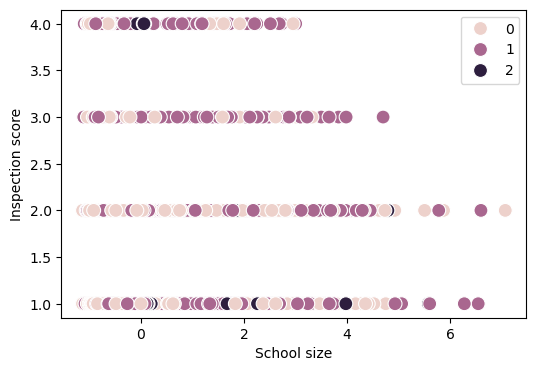

In [45]:
# Investigate school size and OE

plt.figure(figsize=(6,4))
ax = sns.scatterplot(x=df_num2['Total pupils'], y=df_num2['OE'], hue=kmeans.labels_, s=100) 

ax.grid(False) # This removes the grid from the background.
plt.xlabel('School size') # Label x-axis.
plt.ylabel('Inspection score') # Label y-axis.
plt.show()

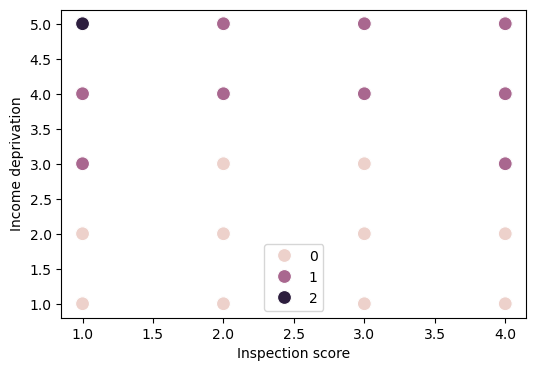

In [46]:
# Investigate inspection score and income deprivation

plt.figure(figsize=(6,4))
ax = sns.scatterplot(x=df_num2['OE'], y=df_num2['IDACI quintile'], hue=kmeans.labels_, s=100) 

ax.grid(False) # This removes the grid from the background.
plt.xlabel('Inspection score') # Label x-axis.
plt.ylabel('Income deprivation') # Label y-axis.
plt.show()

Here, the pink cluster is the least deprived schools and the purple cluster is the most deprived.  The black cluster is concentrated on the most deprived and highest inspection score: these are schools in very deprived areas with excellent inspection results.

In [48]:
df_num2.loc[df_num2['clusters'] == 2, 'cluster'] = 'black'
df_num2.loc[df_num2['clusters'] == 1, 'cluster'] = 'purple'
df_num2.loc[df_num2['clusters'] == 0, 'cluster'] = 'pink'

C:\Users\cathe\AppData\Local\Temp\ipykernel_15024\186726598.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num2.loc[df_num2['clusters'] == 2, 'cluster'] = 'black'


In [49]:
# Calculate summary statistics of clusters
df_num2.groupby('cluster').agg({'Total pupils':['mean', 'median'], 
                         'LA Pop Density':['mean', 'median'], 
                         'OE':['mean', 'median'],
                          'IDACI quintile':['mean', 'median']})

Total pupils           LA Pop Density                  OE         \
                mean    median           mean    median      mean median   
cluster                                                                    
black       0.099133 -0.074199       0.089968  0.432626  1.937309    2.0   
pink       -0.076615 -0.498314      -0.469910 -0.700380  1.932910    2.0   
purple      0.042853 -0.218238       0.319014 -0.062455  1.976397    2.0   

        IDACI quintile         
                  mean median  
cluster                        
black         4.096330    5.0  
pink          2.015866    2.0  
purple        4.395483    4.0

- The clusters have very similar average inspection results (OE).
- The black cluster contains schools in the most deprived areas on average; purple the least deprived.
- The pink cluster has the highest mean population density.  It is quite a skewed distribution, with the mean higher than the median.

Proposed next steps:
- Combine df_num2 with the original unstandardised values to help interpretation of the clusters